<a href="https://colab.research.google.com/github/divyansshu/pytorch/blob/main/pytorch_computer_vision.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Computer Vision Libraries in pytorch
1. `torchvision`: base domain library for ptytorch computer vision
2. `torchvision.datasets`: get datasets and dataloading functions for computer vision here
3. `torchvision.models`: get pretrained computer vision models that you can leverage for your own problems
4. `torchvision.transforms`: functions for manipulating your vision data (images) to be suitable for use with an ML model
5. `torch.utils.data.Dataset`: Base dataset class for pytorch
6. `torch.utils.data.DataLoader`: creates a python iterable for dataset

In [1]:
import torch
from torch import nn
import torchvision
from torchvision import datasets,transforms
from torchvision.transforms import ToTensor
import matplotlib.pyplot as plt

print(torch.__version__)
print(torchvision.__version__)

2.11.0+cpu
0.26.0+cpu


In [2]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'
device

'cpu'

In [3]:
train_data = datasets.FashionMNIST(
    root='data',
    train=True,
    download=True,
    transform=ToTensor(),
    target_transform=None
)

test_data = datasets.FashionMNIST(
    root='data',
    train=False,
    download=True,
    transform=ToTensor(),
    target_transform=None

)

100%|██████████| 26.4M/26.4M [00:01<00:00, 17.8MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 279kB/s]
100%|██████████| 4.42M/4.42M [00:00<00:00, 5.07MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 7.78MB/s]


In [4]:
len(train_data), len(test_data)

(60000, 10000)

In [5]:
image, label = train_data[0]
image, label

(tensor([[[0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000],
          [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000],
          [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000],
          [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0039, 0.0000, 0.0000, 0.0510,
           0.2863, 0.0000, 0.0000, 0.0039, 

In [6]:
image.shape

torch.Size([1, 28, 28])

In [7]:
class_names = train_data.classes
class_names

['T-shirt/top',
 'Trouser',
 'Pullover',
 'Dress',
 'Coat',
 'Sandal',
 'Shirt',
 'Sneaker',
 'Bag',
 'Ankle boot']

In [8]:
class_idx = train_data.class_to_idx
class_idx

{'T-shirt/top': 0,
 'Trouser': 1,
 'Pullover': 2,
 'Dress': 3,
 'Coat': 4,
 'Sandal': 5,
 'Shirt': 6,
 'Sneaker': 7,
 'Bag': 8,
 'Ankle boot': 9}

Text(0.5, 1.0, '9')

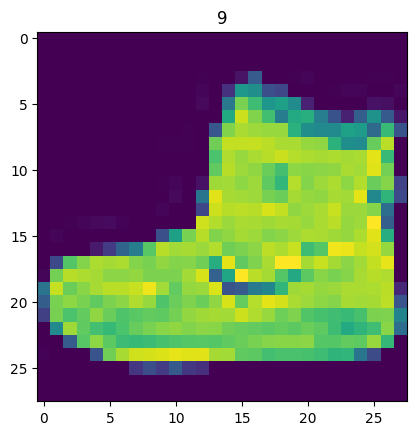

In [9]:
image, label = train_data[0]
plt.imshow(image.squeeze())
plt.title(label)

(np.float64(-0.5), np.float64(27.5), np.float64(27.5), np.float64(-0.5))

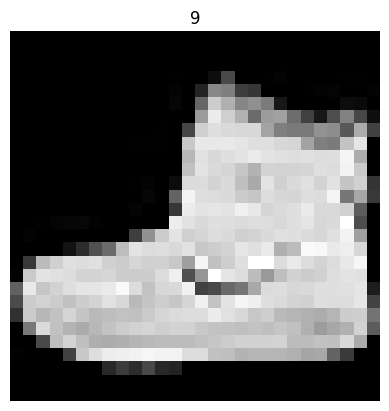

In [10]:
plt.imshow(image.squeeze(), cmap='gray')
plt.title(label)
plt.axis(False)

right now our data is in pytorch datasets
DataLoader turns our dataset into python iterable
more specifically, we want to turn our data into batches.


In [11]:
from torch.utils.data import DataLoader
BATCH_SIZE=32

# turn datasets into iterable (batches)
train_dataLoader = DataLoader(dataset=train_data,
                              batch_size=BATCH_SIZE,
                              shuffle=True)
test_dataLoader = DataLoader(dataset=test_data,
                             batch_size=32,
                             shuffle=False)

In [12]:
print(f'length of train_dataloader: {len(train_dataLoader)} batches of {BATCH_SIZE}')
print(f'length of test_dataloader: {len(test_dataLoader)} batches of {BATCH_SIZE}')

length of train_dataloader: 1875 batches of 32
length of test_dataloader: 313 batches of 32


In [13]:
train_features_batch, train_labels_batch = next(iter(train_dataLoader))
train_features_batch.shape, train_labels_batch.shape

(torch.Size([32, 1, 28, 28]), torch.Size([32]))

Image size: torch.Size([1, 28, 28])
Label: 2, label size: torch.Size([])


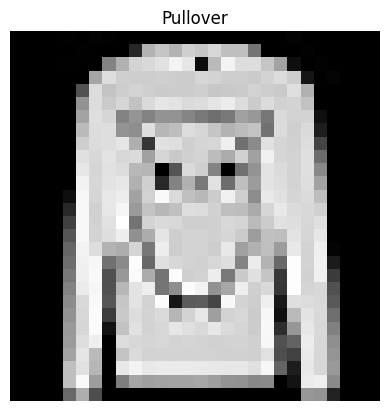

In [14]:
random_idx = torch.randint(0, len(train_features_batch), size=[1]).item()
img, label = train_features_batch[random_idx], train_labels_batch[random_idx]
plt.imshow(img.squeeze(), cmap='gray')
plt.title(class_names[label])
plt.axis(False)
print(f'Image size: {img.shape}')
print(f'Label: {label}, label size: {label.shape}')

In [15]:
flatten_model = nn.Flatten()
x = train_features_batch[0]
output = flatten_model(x)

print(f'Shape before flattening: {x.shape}')
print(f'Shape after flattening: {output.shape}')

Shape before flattening: torch.Size([1, 28, 28])
Shape after flattening: torch.Size([1, 784])


In [16]:
#  1. Baseline model- linear
# class FashionMNISTModel(nn.Module):
#   def __init__(self, input_shape, hidden_units, output_shape):
#     super().__init__()

#     self.layers_stack = nn.Sequential(
#         nn.Flatten(),
#         nn.Linear(in_features=input_shape, out_features=hidden_units),
#         nn.Linear(in_features=hidden_units, out_features=output_shape)
#     )

#   def forward(self, x):
#     return self.layers_stack(x)

In [17]:
# 2. Introducing non linearity in baseline model
# class FashionMNISTModel(nn.Module):
#   def __init__(self, input_shape, hidden_units, output_shape):
#     super().__init__()

#     self.layers_stack = nn.Sequential(
#         nn.Flatten(),
#         nn.Linear(input_shape, hidden_units),
#         nn.ReLU(),
#         nn.Linear(hidden_units, output_shape),
#         nn.ReLU()
#     )

#   def forward(self, x):
#     return self.layers_stack(x)

In [18]:
# 3. create a convolutional neural network
class FashionMNISTModel_v2(nn.Module):
  def __init__(self, input_shape, hidden_units, output_shape):
    super().__init__()
    self.conv_block_1 = nn.Sequential(
        nn.Conv2d(in_channels=input_shape, out_channels=hidden_units,
        kernel_size=3, stride=1, padding=1),
        nn.ReLU(),
        nn.Conv2d(in_channels=hidden_units, out_channels=hidden_units, kernel_size=3, stride=1, padding=1),
        nn.ReLU(),
        nn.MaxPool2d(kernel_size=2)
    )

    self.conv_block_2 = nn.Sequential(
        nn.Conv2d(in_channels=hidden_units, out_channels=hidden_units,
        kernel_size=3, stride=1, padding=1),
        nn.ReLU(),
        nn.Conv2d(in_channels=hidden_units, out_channels=hidden_units, kernel_size=3, stride=1, padding=1),
        nn.ReLU(),
        nn.MaxPool2d(kernel_size=2)
    )

    self.classifier = nn.Sequential(
        nn.Flatten(),
        nn.Linear(in_features=490,
                  out_features=output_shape)
    )

  def forward(self, x):
    x = self.conv_block_1(x)
    # print(f'output shape of conv2d layer 1 {x.shape}')
    x = self.conv_block_2(x)
    # print(f'output shape of conv2d layer 2 {x.shape}')
    x = self.classifier(x)
    # print(f'shape of classifier layer {x.shape}')
    return x

In [19]:
model_0 = FashionMNISTModel_v2(
    input_shape=1,
    hidden_units=10,
    output_shape=len(class_names)).to(device)
model_0

FashionMNISTModel_v2(
  (conv_block_1): Sequential(
    (0): Conv2d(1, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): Conv2d(10, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU()
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (conv_block_2): Sequential(
    (0): Conv2d(10, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): Conv2d(10, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU()
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=490, out_features=10, bias=True)
  )
)

In [20]:
torch.manual_seed(42)

# create a batch of images
images = torch.randn(size=(32,1,28,28))
test_image = images[0]
print(f'Images shape: {images.shape}')
print(f'test images shape: {test_image.shape}')

Images shape: torch.Size([32, 1, 28, 28])
test images shape: torch.Size([1, 28, 28])


In [21]:
# # create a single conv2d layer
# conv_layer = nn.Conv2d(
#     in_channels=1,
#     out_channels=10,
#     kernel_size=3,
#     stride=1,
#     padding=0
# )

# conv_output = conv_layer(test_image)
# conv_output.shape

output = model_0(images)
output.shape

torch.Size([32, 10])

In [22]:
# sample maxpool2d layer
max_pool = nn.MaxPool2d(kernel_size=2)
max_pool_output = max_pool(conv_output)
max_pool_output.shape

NameError: name 'conv_output' is not defined

In [23]:
random_image_tensor = torch.randn(size=(1,28,28))
random_image_tensor.shape

torch.Size([1, 28, 28])

In [24]:
# pass this random image to cnn model
model_0(random_image_tensor).to(device)

RuntimeError: mat1 and mat2 shapes cannot be multiplied (10x49 and 490x10)

In [25]:
next(model_0.parameters()).device

device(type='cpu')

In [26]:
# calculate accuracy
def accuracy(y_true, y_pred):
  correct = torch.eq(y_pred, y_true).sum().item()
  acc = (correct / len(y_pred)) * 100
  return acc

In [27]:
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(params=model_0.parameters(), lr=0.01)

In [28]:
from tqdm.auto import tqdm # progress bar
epochs = 5

for epoch in tqdm(range(epochs)):
  print(f'Epoch: {epoch}\n------------')
  train_loss = 0
  for X, y in train_dataLoader:
    X, y = X.to(device), y.to(device)
    model_0.train()

    y_pred = model_0(X)
    loss = loss_fn(y_pred, y)
    train_loss += loss
    train_acc = accuracy(y, y_pred.argmax(dim=1))

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

  train_loss /= len(train_dataLoader)

  test_loss, test_acc = 0,0
  model_0.to(device)
  model_0.eval()
  with torch.inference_mode():
    for X,y in test_dataLoader:
      X, y = X.to(device), y.to(device)
      test_preds = model_0(X)
      test_loss += loss_fn(test_preds, y)
      test_acc += accuracy(y, test_preds.argmax(dim=1))
    test_loss /= len(test_dataLoader)
    test_acc /= len(test_dataLoader)

  print(f'Train loss: {train_loss:.5f} Train accuracy: {train_acc:.2f}% Test loss: {test_loss:.5f} Test accuracy: {test_acc:.2f}%')


  0%|          | 0/5 [00:00<?, ?it/s]

Epoch: 0
------------
Train loss: 0.45888 Train accuracy: 87.50% Test loss: 0.38174 Test accuracy: 86.03%
Epoch: 1
------------
Train loss: 0.36304 Train accuracy: 84.38% Test loss: 0.34689 Test accuracy: 87.43%
Epoch: 2
------------
Train loss: 0.34588 Train accuracy: 84.38% Test loss: 0.37026 Test accuracy: 86.17%
Epoch: 3
------------
Train loss: 0.33799 Train accuracy: 93.75% Test loss: 0.38818 Test accuracy: 86.35%
Epoch: 4
------------
Train loss: 0.33631 Train accuracy: 96.88% Test loss: 0.34489 Test accuracy: 87.45%


In [29]:
def make_predictions(model: torch.nn.Module,
                     data:list,
                     device: torch.device = device):
  pred_probs = []
  model.eval()
  with torch.inference_mode():
    for sample in data:

      # add a batch dimension to the sample
      sample = torch.unsqueeze(sample, dim=0).to(device)

      # froward pass model predicts raw logits
      pred_logits = model(sample)
      # get prediction probabilities (logit -> prediction probabilities)
      pred_prob = torch.softmax(pred_logits.squeeze(), dim=0)

      pred_probs.append(pred_prob)
  return torch.stack(pred_probs)



In [47]:
import random
# random.seed(42)
test_samples = []
test_labels = []
for sample, label in random.sample(list(test_data), k=9):
  test_samples.append(sample)
  test_labels.append(label)


In [40]:
test_samples[0].shape


torch.Size([1, 28, 28])

(np.float64(-0.5), np.float64(27.5), np.float64(27.5), np.float64(-0.5))

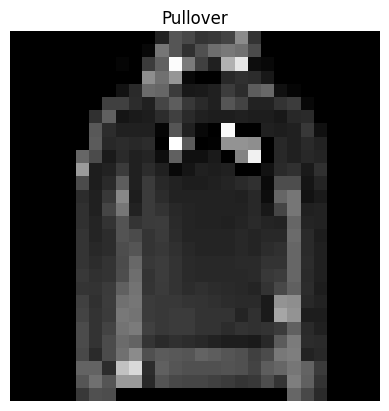

In [48]:
plt.imshow(test_samples[0].squeeze(), cmap='gray')
plt.title(class_names[test_labels[0]])
plt.axis('off')

In [49]:
pred_probs = make_predictions(model_0, test_samples)
pred_probs[:1]

tensor([[1.0834e-02, 4.7451e-03, 6.6275e-01, 2.0935e-02, 1.9589e-01, 1.3700e-05,
         1.0292e-01, 5.2707e-06, 1.8102e-03, 9.6146e-05]])

In [43]:
pred_probs[:1]

tensor([[9.7259e-06, 8.0402e-11, 3.6241e-05, 3.8653e-09, 9.2300e-10, 8.0304e-05,
         6.2350e-06, 6.0700e-03, 4.3492e-07, 9.9380e-01]])

In [50]:
pred_classes = pred_probs.argmax(dim=1)
pred_classes

tensor([2, 4, 4, 3, 2, 2, 0, 1, 1])

In [51]:
test_labels

[2, 4, 6, 3, 2, 2, 0, 1, 1]

(np.float64(-0.5), np.float64(27.5), np.float64(27.5), np.float64(-0.5))

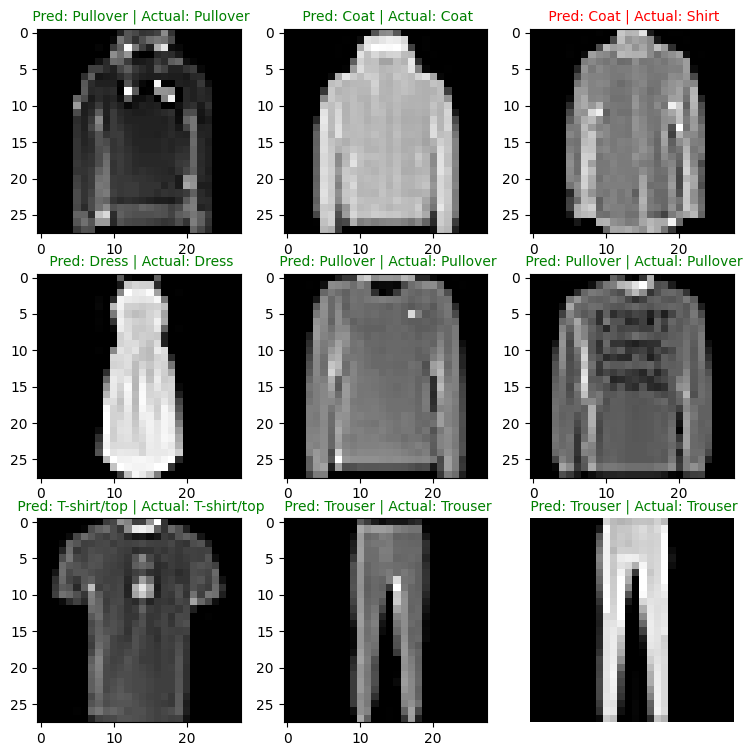

In [52]:
plt.figure(figsize=(9,9))
nrows=3
ncols=3
for i, sample in enumerate(test_samples):
  plt.subplot(nrows, ncols, i+1)

  plt.imshow(sample.squeeze(), cmap='gray')

  pred_label = class_names[pred_classes[i]]

  actual_label = class_names[test_labels[i]]

  title_text = f' Pred: {pred_label} | Actual: {actual_label}'

  if pred_label == actual_label:
    plt.title(title_text, fontsize=10, c='g')
  else:
    plt.title(title_text, fontsize=10, c='r')
plt.axis(False)



In [54]:
from tqdm.auto import tqdm
y_preds = []
with torch.inference_mode():
  for X, y in tqdm(test_dataLoader, desc='Making predictions'):
    X, y = X.to(device), y.to(device)
    # forward pass
    test_logits = model_0(X)
    # logits -> prediction probabilities -> predictions labels
    test_pred = torch.softmax(test_logits, dim=1).argmax(dim=1)
    # put predictions on cpu for evaluation
    y_preds.append(test_pred.cpu())

# concatenate list of predictions into a tensor
y_preds_tensor = torch.cat(y_preds)

Making predictions:   0%|          | 0/313 [00:00<?, ?it/s]

In [56]:
len(y_preds_tensor)

10000

In [57]:
!pip install torchmetrics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.4/983.4 kB 16.2 MB/s eta 0:00:00


In [58]:
!pip install mlxtend

In [59]:
import torchmetrics, mlxtend
print(f'mlxtend version: {mlxtend.__version__}')

mlxtend version: 0.23.4


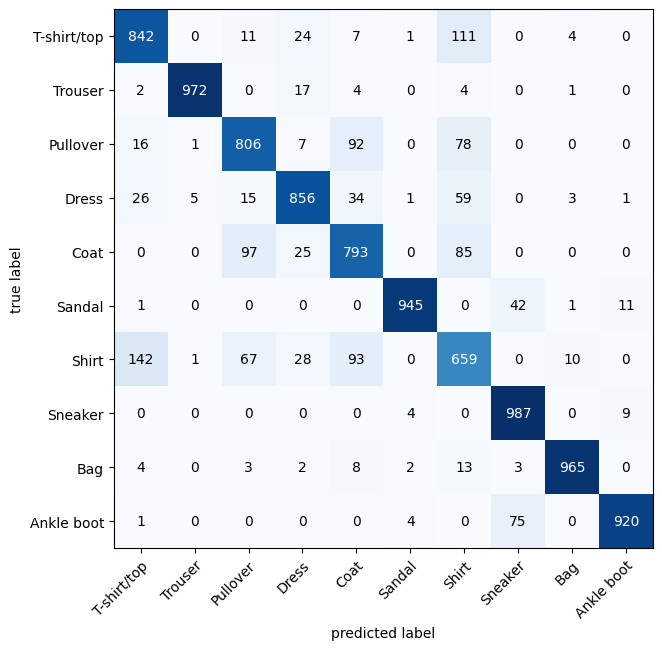

In [60]:
from torchmetrics import ConfusionMatrix
from mlxtend.plotting import plot_confusion_matrix

conf_mat = ConfusionMatrix(num_classes=len(class_names), task='multiclass')
conf_tensor = conf_mat(preds=y_preds_tensor,
                       target=test_data.targets)

# plot the confusion matrix
fig, ax = plot_confusion_matrix(
    conf_mat=conf_tensor.numpy(),  # matplotlib likes working with numpy
    class_names = class_names, # turn the row and column labels into class names
    figsize=(10,7)
)